In [2]:
%pip install tbparse pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import math
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tbparse import SummaryReader

# ---> UPDATE THIS to point to your actual TensorBoard log directory
# Example: './logs/20260309-100000' or wherever your run was saved
LOG_DIR = './logs/20260324-093205/${PPO_LSTM_Run3_final}' 

# Read TensorBoard logs
print("Parsing TensorBoard logs... This might take a moment.")
reader = SummaryReader(LOG_DIR, pivot=True)

# Depending on tbparse version, tf.summary.scalar goes to either scalars or tensors
try:
    df_rppo = reader.scalars
    if df_rppo.empty:
        df_rppo = reader.tensors
except AttributeError:
    df_rppo = reader.tensors

print("Available metrics:", df_rppo.columns.tolist())

2026-03-31 21:05:56.058801: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-31 21:05:56.142716: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-31 21:05:57.949679: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Parsing TensorBoard logs... This might take a moment.
Available metrics: ['step', 'action', 'action_feedback', 'avg_execution_time', 'cpu', 'episode', 'episodic_reward', 'mean_reward', 'mem', 'n-step_reward', 'replicas', 'requests', 'throughput']


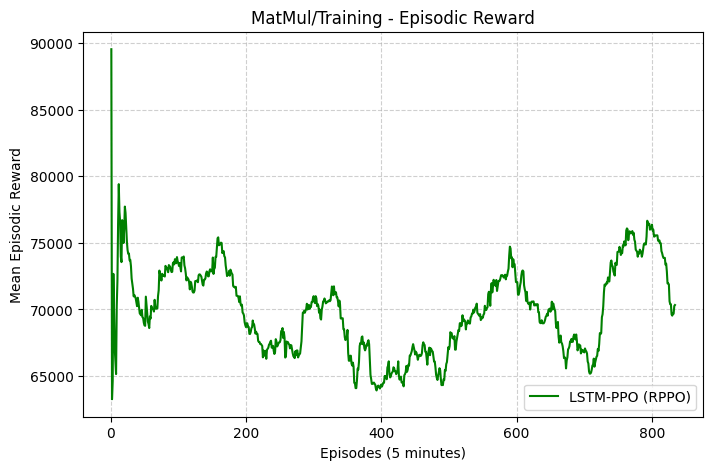

In [2]:
# The paper evaluates the episodes across the first ~500 episodes
# Drop NaNs specific to the 'mean_reward' column 
df_rewards = df_rppo[['step', 'mean_reward']].dropna()

# In your environment, mean_reward was logged using 'episode' as the step.
rppox = df_rewards['step'].to_numpy() 
rppoy = df_rewards['mean_reward'].to_numpy()

plt.figure(figsize=(8, 5))
plt.plot(rppox, rppoy, color='green')
plt.xlabel('Episodes (5 minutes)')
plt.ylabel('Mean Episodic Reward')
plt.title('MatMul/Training - Episodic Reward')
plt.legend(['LSTM-PPO (RPPO)'], loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

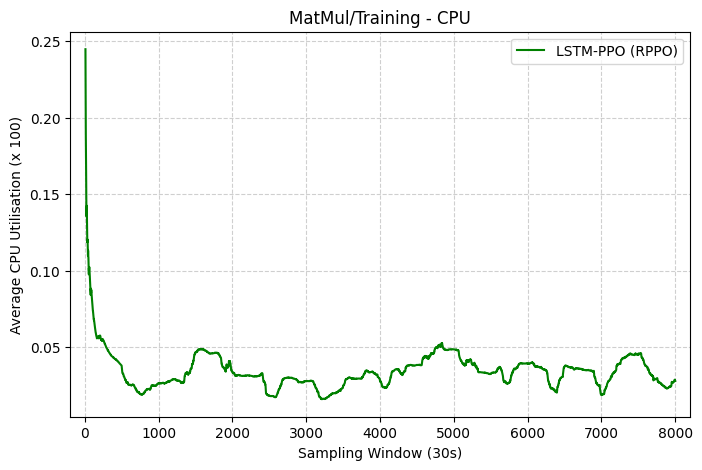

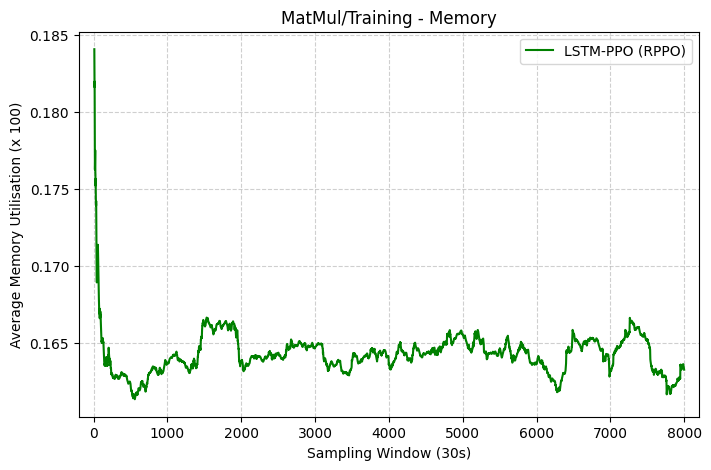

In [15]:
# Filter data to only include steps up to 8000
df_cpu_filtered = df_rppo[df_rppo['step'] <= 8000][['step', 'cpu']].dropna()
df_mem_filtered = df_rppo[df_rppo['step'] <= 8000][['step', 'mem']].dropna()

# Padding value to keep 0 and 8000 away from the edges
padding = 200 

# --- CPU Utilization ---
rppox_cpu = df_cpu_filtered['step'].to_numpy()
rppoy_cpu = df_cpu_filtered['cpu'].rolling(window=500, min_periods=10).mean().to_numpy()

plt.figure(figsize=(8, 5))
plt.plot(rppox_cpu, rppoy_cpu, color='green')

# Set limits to start before 0 and end after 8000
plt.xlim(0 - padding, 8000 + padding) 

plt.xlabel('Sampling Window (30s)')
plt.ylabel('Average CPU Utilisation (x 100)')
plt.title('MatMul/Training - CPU')
plt.legend(['LSTM-PPO (RPPO)'], loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- Memory Utilization ---
rppox_mem = df_mem_filtered['step'].to_numpy()
rppoy_mem = df_mem_filtered['mem'].rolling(window=500, min_periods=10).mean().to_numpy()

plt.figure(figsize=(8, 5))
plt.plot(rppox_mem, rppoy_mem, color='green')

# Set limits to start before 0 and end after 8000
plt.xlim(0 - padding, 8000 + padding)

plt.xlabel('Sampling Window (30s)')
plt.ylabel('Average Memory Utilisation (x 100)')
plt.title('MatMul/Training - Memory')
plt.legend(['LSTM-PPO (RPPO)'], loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

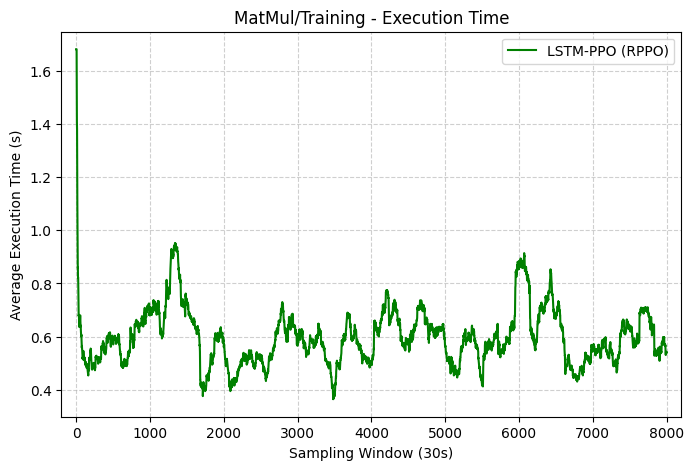

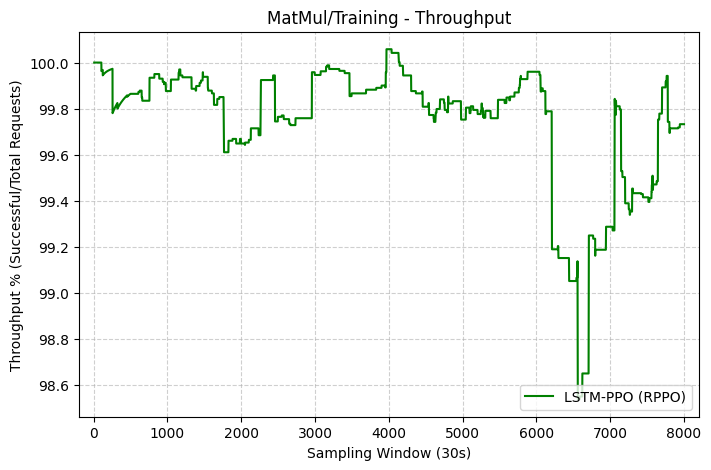

In [16]:
# Filter data to only include steps up to 8000
df_exec_filtered = df_rppo[df_rppo['step'] <= 8000][['step', 'avg_execution_time']].dropna()
df_thr_filtered = df_rppo[df_rppo['step'] <= 8000][['step', 'throughput']].dropna()

# Padding to keep 0 and 8000 away from the left and right edges
padding = 200

# --- Average Execution Time ---
# (Using the 200-step rolling window as per your original code)
rppox_exec = df_exec_filtered['step'].to_numpy()
rppoy_exec = df_exec_filtered['avg_execution_time'].rolling(window=200, min_periods=1).mean().to_numpy()

plt.figure(figsize=(8, 5))
plt.plot(rppox_exec, rppoy_exec, color='green')

# Set limits to create the requested "breathing room" at the edges
plt.xlim(0 - padding, 8000 + padding)

plt.xlabel('Sampling Window (30s)')
plt.ylabel('Average Execution Time (s)')
plt.title('MatMul/Training - Execution Time')
plt.legend(['LSTM-PPO (RPPO)'], loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- Throughput ---
# (Using the 500-step rolling window as per your original code)
rppox_thr = df_thr_filtered['step'].to_numpy()
rppoy_thr = df_thr_filtered['throughput'].rolling(window=500, min_periods=10).mean().to_numpy()

plt.figure(figsize=(8, 5))
plt.plot(rppox_thr, rppoy_thr, color='green')

# Set limits to create the requested "breathing room" at the edges
plt.xlim(0 - padding, 8000 + padding)

plt.xlabel('Sampling Window (30s)')
plt.ylabel('Throughput % (Successful/Total Requests)')
plt.title('MatMul/Training - Throughput')
plt.legend(['LSTM-PPO (RPPO)'], loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

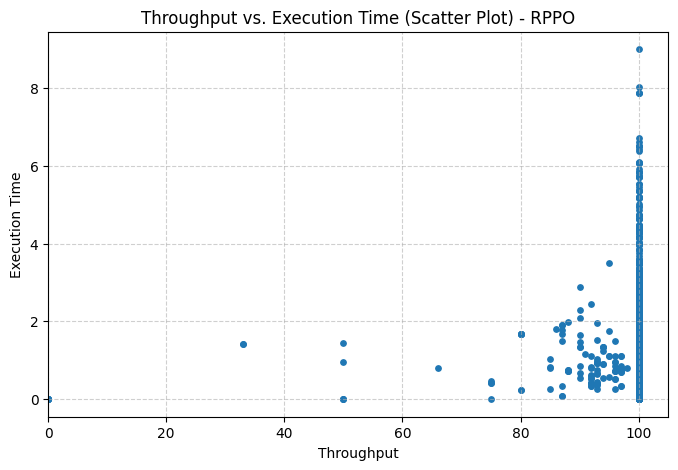

In [17]:
# For the scatter plot, we align the raw arrays directly without the rolling windows
df_scatter = df_rppo[['throughput', 'avg_execution_time']].dropna()

throughput = df_scatter['throughput'].to_numpy()
response_time = df_scatter['avg_execution_time'].to_numpy()

plt.figure(figsize=(8, 5))
plt.scatter(throughput, response_time, color='#1f77b4', s=15) # Standard blue scatter dots
plt.xlabel('Throughput')
plt.ylabel('Execution Time')
plt.title('Throughput vs. Execution Time (Scatter Plot) - RPPO')
plt.xlim(0, 105) # Keep x-axis aligned to percentages as per paper
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

TEST ENV/ AGENT

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tbparse import SummaryReader

# ---> UPDATE THIS to point to your exact evaluation log directory
# E.g., './logs/evaluation/20260309-123456/PPO_LSTM_Run1_2'
EVAL_LOG_DIR = './logs/evaluation/20260327-211231/PPO_LSTM_Run3_final' 

print("Parsing Evaluation TensorBoard logs...")
reader = SummaryReader(EVAL_LOG_DIR, pivot=True)

# Extract tensors
try:
    df_eval = reader.scalars
    if df_eval.empty:
        df_eval = reader.tensors
except AttributeError:
    df_eval = reader.tensors

# Drop NaNs to ensure all metrics align by step
df_eval = df_eval[['step', 'throughput', 'avg_execution_time', 'replicas']].dropna()

# The paper evaluates exactly 200 sampling windows for the testing phase
df_eval = df_eval.head(200)

throughput = df_eval['throughput'].to_numpy()
execution_time = df_eval['avg_execution_time'].to_numpy()
replicas = df_eval['replicas'].to_numpy()

print(f"Loaded {len(df_eval)} evaluation samples.")

Parsing Evaluation TensorBoard logs...
Loaded 200 evaluation samples.


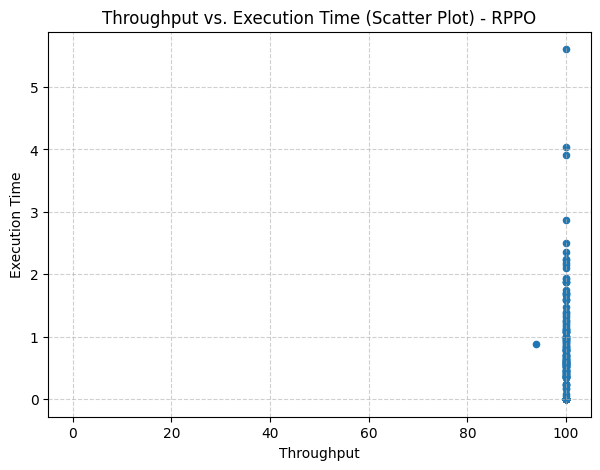

In [7]:
plt.figure(figsize=(7, 5))
# The paper uses standard blue scatter dots for all individual scatter plots
plt.scatter(throughput, execution_time, color='#1f77b4', s=20) 

plt.xlabel('Throughput')
plt.ylabel('Execution Time')
plt.title('Throughput vs. Execution Time (Scatter Plot) - RPPO')
plt.xlim(-5, 105) # Match the paper's 0-100 x-axis view
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

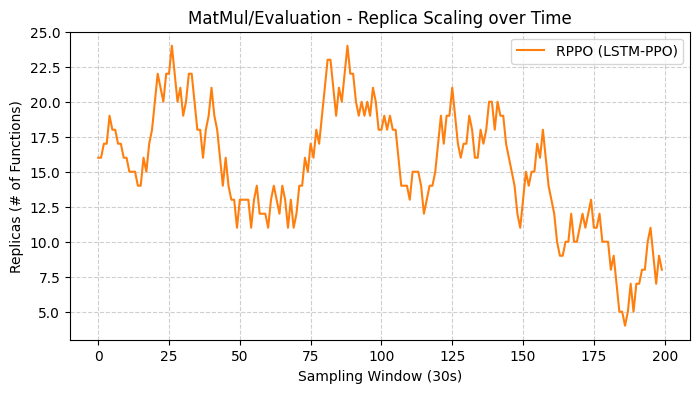

In [8]:
steps = np.arange(len(replicas))

plt.figure(figsize=(8, 4))
plt.plot(steps, replicas, color='tab:orange', label='RPPO (LSTM-PPO)')
plt.xlabel('Sampling Window (30s)')
plt.ylabel('Replicas (# of Functions)')
plt.title('MatMul/Evaluation - Replica Scaling over Time')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

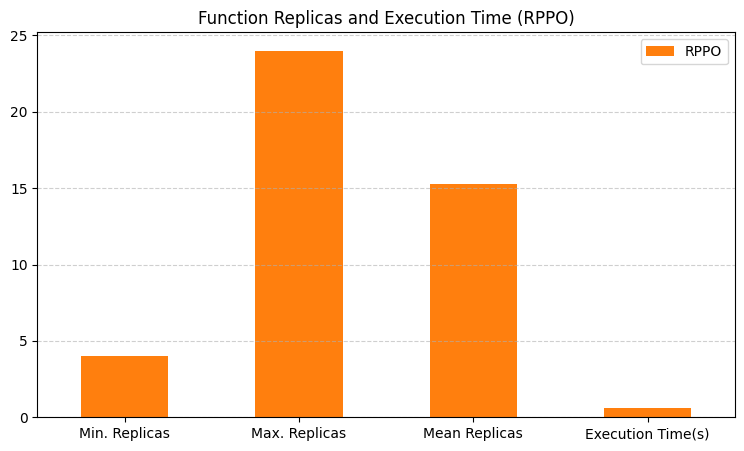

                        RPPO
Min. Replicas       4.000000
Max. Replicas      24.000000
Mean Replicas      15.295000
Execution Time(s)   0.630755


In [9]:
# Calculate the exact metrics the authors used for Figure 5(d)
rppo_min_rep = np.min(replicas)
rppo_max_rep = np.max(replicas)
rppo_mean_rep = np.mean(replicas)
rppo_mean_exec = np.mean(execution_time)

# I used 'tab:orange' to match the color of RPPO in the paper's bar charts.
# You can add 'PPO': [...] and 'DRQN': [...] to this dictionary later!
data_rep = {
    'RPPO':[rppo_min_rep, rppo_max_rep, rppo_mean_rep, rppo_mean_exec]
}

df_rep_chart = pd.DataFrame(data_rep, index=['Min. Replicas', 'Max. Replicas', 'Mean Replicas', 'Execution Time(s)'])

# Plotting
ax = df_rep_chart.plot.bar(figsize=(9, 5), color=['tab:orange'])
plt.title('Function Replicas and Execution Time (RPPO)')
plt.xticks(rotation=0) # Keep labels horizontal
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.show()

# Print the exact numbers for your records
print(df_rep_chart)

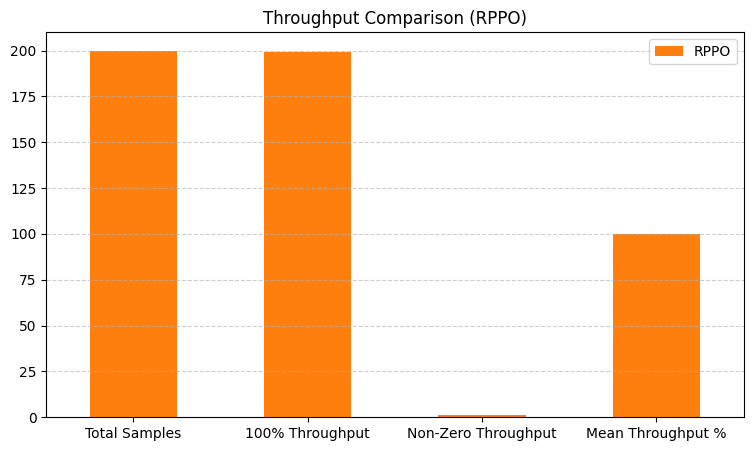

                       RPPO
Total Samples        200.00
100% Throughput      199.00
Non-Zero Throughput    1.00
Mean Throughput %     99.97


In [10]:
# Calculate the exact categorizations the authors used for Figure 5(e)
total_samples = len(throughput)
throughput_100 = np.sum(throughput == 100)
# "Non-Zero Throughput" in their script meant > 0 but strictly < 100 (struggling requests)
throughput_nonzero = np.sum((throughput > 0) & (throughput < 100)) 
mean_throughput_pct = np.mean(throughput)

data_thr = {
    'RPPO':[total_samples, throughput_100, throughput_nonzero, mean_throughput_pct]
}

df_thr_chart = pd.DataFrame(data_thr, index=['Total Samples', '100% Throughput', 'Non-Zero Throughput', 'Mean Throughput %'])

# Plotting
ax = df_thr_chart.plot.bar(figsize=(9, 5), color=['tab:orange'])
plt.title('Throughput Comparison (RPPO)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.show()

# Print the exact numbers for your records
print(df_thr_chart)

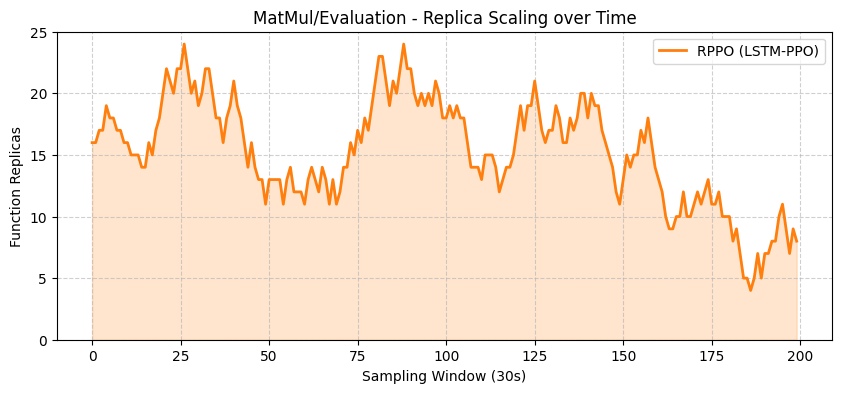

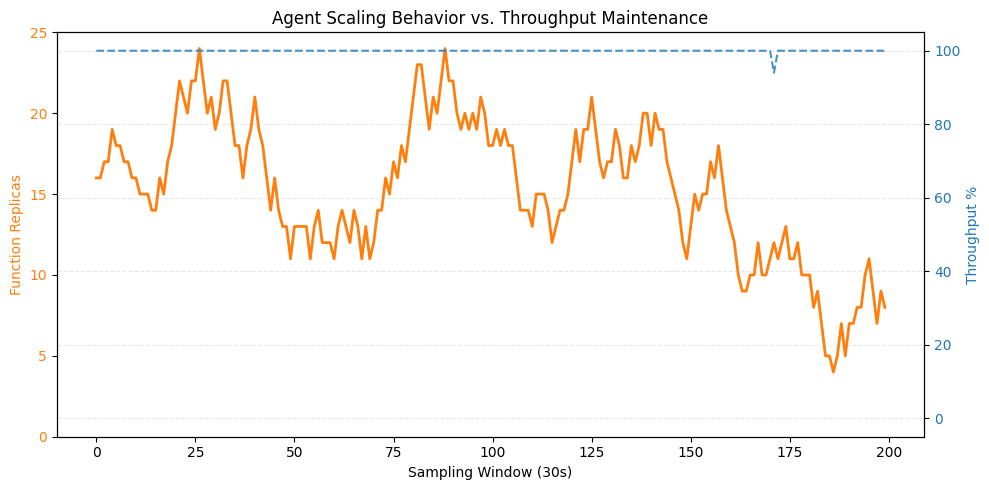

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure your dataframe is loaded properly with the required columns
# (This assumes df_eval is already extracted from your TensorBoard reader)
cols_to_keep =['step', 'replicas', 'throughput', 'action', 'cpu', 'mem', 'avg_execution_time']
# Safely extract the columns that exist in your eval data
available_cols =[c for c in cols_to_keep if c in df_eval.columns]
df_plot = df_eval[available_cols].dropna().head(200) # Limit to 200 windows as per the paper

steps = df_plot['step'].to_numpy()
replicas = df_plot['replicas'].to_numpy()
throughput = df_plot['throughput'].to_numpy()

# ==========================================
# PLOT 1: Replica Count over Time
# ==========================================
plt.figure(figsize=(10, 4))
plt.plot(steps, replicas, color='tab:orange', linewidth=2, label='RPPO (LSTM-PPO)')
plt.fill_between(steps, replicas, alpha=0.2, color='tab:orange') # Adds a nice shaded area below the line
plt.xlabel('Sampling Window (30s)')
plt.ylabel('Function Replicas')
plt.title('MatMul/Evaluation - Replica Scaling over Time')
plt.ylim(0, 25) # Max pods is 24
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.show()

# ==========================================
# PLOT 2: Dual-Axis - Replicas & Throughput
# ==========================================
# This plot is excellent for papers to prove the agent scales *to preserve* throughput
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:orange'
ax1.set_xlabel('Sampling Window (30s)')
ax1.set_ylabel('Function Replicas', color=color)
ax1.plot(steps, replicas, color=color, linewidth=2, label='Replicas')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 25)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Throughput %', color=color)  
ax2.plot(steps, throughput, color=color, linestyle='--', linewidth=1.5, alpha=0.8, label='Throughput')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(-5, 105)

plt.title('Agent Scaling Behavior vs. Throughput Maintenance')
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# ==========================================
# PLOT 3: Action Distribution (Agent Policy Analysis)
# ==========================================
if 'action' in df_plot.columns:
    actions = df_plot['action'].to_numpy()
    
    # In your test script, you mapped actions before logging them 
    # so they should already be in the format: -2, -1, 0, 1, 2
    unique_actions, counts = np.unique(actions, return_counts=True)
    
    plt.figure(figsize=(7, 4))
    bars = plt.bar(unique_actions, counts, color='tab:green', edgecolor='black', alpha=0.8)
    plt.xlabel('Action Taken (Change in Replica Count)')
    plt.ylabel('Frequency (over 200 windows)')
    plt.title('Action Distribution - How the Agent Scales')
    plt.xticks([-2, -1, 0, 1, 2])
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Add data labels on top of bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom')
        
    plt.show()

# ==========================================
# PLOT 4: Resource Utilization (CPU & Memory)
# ==========================================
if 'cpu' in df_plot.columns and 'mem' in df_plot.columns:
    cpu = df_plot['cpu'].to_numpy() * 100 # Convert to percentage based on your reward logic
    mem = df_plot['mem'].to_numpy() * 100
    
    plt.figure(figsize=(10, 4))
    plt.plot(steps, cpu, color='tab:red', linewidth=1.5, label='CPU Utilization (%)')
    plt.plot(steps, mem, color='tab:purple', linewidth=1.5, label='Memory Utilization (%)')
    
    plt.xlabel('Sampling Window (30s)')
    plt.ylabel('Resource Utilization (%)')
    plt.title('MatMul/Evaluation - Average Resource Utilization')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()